# Phase 5 - Step 1: Setup + Logistic Regression (with Oversampling)

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

# Load processed splits (from Phase 3)
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Apply the WINNING technique from Phase 4: Oversampling (only on training data)
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print('Resampled training shape:', X_train_res.shape)
print('Class balance after oversampling:', y_train_res.value_counts().to_dict())

# Dictionary to store all model results for later comparison (Phase 5 report)
model_results = {}

def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    metrics = {
        'Precision': precision_score(y_eval, y_pred),
        'Recall': recall_score(y_eval, y_pred),
        'F1': f1_score(y_eval, y_pred),
        'ROC-AUC': roc_auc_score(y_eval, y_proba),
        'PR-AUC': average_precision_score(y_eval, y_proba)
    }
    model_results[name] = metrics
    print(f'--- {name} ---')
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_eval, y_pred))
    return metrics

Resampled training shape: (396554, 30)
Class balance after oversampling: {0: 198277, 1: 198277}


In [2]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

evaluate_model('Logistic Regression', log_reg, X_val, y_val)

--- Logistic Regression ---
Precision: 0.0509
Recall: 0.8873
F1: 0.0963
ROC-AUC: 0.9716
PR-AUC: 0.6990

Confusion Matrix:
[[41314  1174]
 [    8    63]]


{'Precision': 0.05092966855295069,
 'Recall': 0.8873239436619719,
 'F1': 0.0963302752293578,
 'ROC-AUC': 0.9715946308618042,
 'PR-AUC': 0.6989586661610807}

# Step 2: Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

evaluate_model('Random Forest', rf_model, X_val, y_val)

--- Random Forest ---
Precision: 0.7941
Recall: 0.7606
F1: 0.7770
ROC-AUC: 0.9755
PR-AUC: 0.7931

Confusion Matrix:
[[42474    14]
 [   17    54]]


{'Precision': 0.7941176470588235,
 'Recall': 0.7605633802816901,
 'F1': 0.7769784172661871,
 'ROC-AUC': 0.9755148761141506,
 'PR-AUC': 0.7930771027229335}

# Step 3: XGBoost

In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)

evaluate_model('XGBoost', xgb_model, X_val, y_val)

--- XGBoost ---
Precision: 0.9636
Recall: 0.7465
F1: 0.8413
ROC-AUC: 0.9823
PR-AUC: 0.8235

Confusion Matrix:
[[42486     2]
 [   18    53]]


{'Precision': 0.9636363636363636,
 'Recall': 0.7464788732394366,
 'F1': 0.8412698412698413,
 'ROC-AUC': 0.9823018794370441,
 'PR-AUC': 0.8235358621291233}

# Step 4: LightGBM

In [5]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train_res, y_train_res)

evaluate_model('LightGBM', lgbm_model, X_val, y_val)

--- LightGBM ---
Precision: 0.9444
Recall: 0.7183
F1: 0.8160
ROC-AUC: 0.9803
PR-AUC: 0.8253

Confusion Matrix:
[[42485     3]
 [   20    51]]


{'Precision': 0.9444444444444444,
 'Recall': 0.7183098591549296,
 'F1': 0.816,
 'ROC-AUC': 0.9802877233273488,
 'PR-AUC': 0.825287877874427}

# Step 5: Final Comparison Table (Phase 5)

In [6]:
model_comparison_df = pd.DataFrame(model_results).T
model_comparison_df = model_comparison_df.round(4)
model_comparison_df = model_comparison_df.sort_values('PR-AUC', ascending=False)

print('=== Supervised Model Comparison (Validation Set) ===\n')
print(model_comparison_df)

best_model_name = model_comparison_df.index[0]
print('\nBest model by PR-AUC:', best_model_name)

=== Supervised Model Comparison (Validation Set) ===

                     Precision  Recall      F1  ROC-AUC  PR-AUC
LightGBM                0.9444  0.7183  0.8160   0.9803  0.8253
XGBoost                 0.9636  0.7465  0.8413   0.9823  0.8235
Random Forest           0.7941  0.7606  0.7770   0.9755  0.7931
Logistic Regression     0.0509  0.8873  0.0963   0.9716  0.6990

Best model by PR-AUC: LightGBM


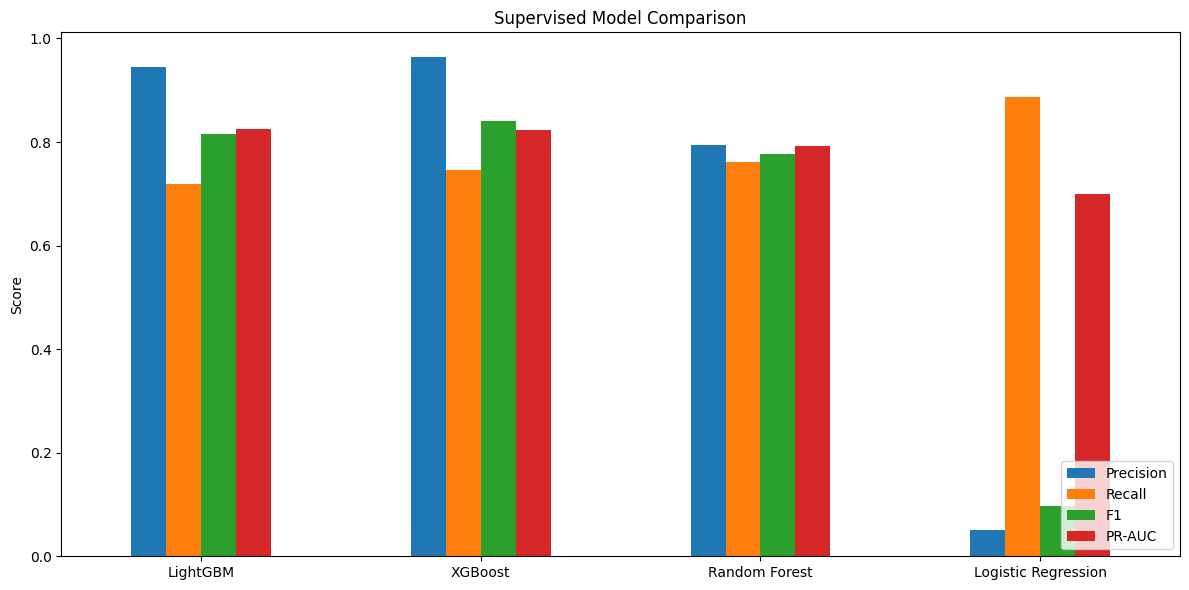

In [7]:
import matplotlib.pyplot as plt

model_comparison_df[['Precision', 'Recall', 'F1', 'PR-AUC']].plot(kind='bar', figsize=(12,6))
plt.title('Supervised Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [8]:
# Save comparison table and the best model for later phases
import joblib
import os
os.makedirs('../models', exist_ok=True)

model_comparison_df.to_csv('../models/supervised_model_comparison.csv')

# Map model name back to the actual fitted model object
model_objects = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

best_supervised_model = model_objects[best_model_name]
joblib.dump(best_supervised_model, '../models/best_supervised_model.pkl')

print(f'Saved comparison table to models/supervised_model_comparison.csv')
print(f'Saved best model ({best_model_name}) to models/best_supervised_model.pkl')

Saved comparison table to models/supervised_model_comparison.csv
Saved best model (LightGBM) to models/best_supervised_model.pkl
